# 🌿 EcoScore — Proof of Concept
**Gurtenfestival 2026 · Bern · 15.–18. Juli 2026**

Dieser PoC demonstriert den technischen Kernalgorithmus der EcoScore App gemäss Zielarchitektur (Kapitel 4).

| Pfad | Beschreibung |
|---|---|
| **Pfad A** | Automatische Punktevergabe via Cashless-Karte (Webhook) |
| **Pfad B** | Manuelle Anreise-Erfassung via Transport-Screen |



> Die Transaktionsdaten sind simuliert und repräsentieren reale Webhook-Daten des Cashless-Systems. In der Zielarchitektur werden diese automatisch via API übermittelt (vgl. Kapitel 4.3).

In [111]:
import subprocess
subprocess.run(['pip3', 'install', 'matplotlib', 'ipywidgets', '--break-system-packages'], capture_output=True)
print('✅ Pakete bereit')

✅ Pakete bereit


## 1. Konfiguration
Scoring-Kategorien, Transportoptionen und Reward-Tiers gemäss Datenmodell (Kapitel 4.4).

In [112]:
# Scoring-Kategorien (exakt aus ecoscore_gurten_data.json)
scoring_categories = {
    'food_vegan':       {'points': 10, 'co2_kg': 2.1, 'label': 'Vegane Mahlzeit',       'group': 'Ernährung'},
    'food_vegetarian':  {'points': 8,  'co2_kg': 0.9, 'label': 'Vegetarische Mahlzeit', 'group': 'Ernährung'},
    'food_chicken':     {'points': 6,  'co2_kg': 0.5, 'label': 'Chicken / Fisch',       'group': 'Ernährung'},
    'food_beef':        {'points': 3,  'co2_kg': 0.0, 'label': 'Rindfleischgericht',    'group': 'Ernährung'},
    'waste_cup_use':    {'points': 3,  'co2_kg': 0.2, 'label': 'Mehrwegbecher nutzen',  'group': 'Recycling'},
    'waste_cup_return': {'points': 3,  'co2_kg': 0.2, 'label': 'Becher zurückgeben',    'group': 'Recycling'},
    'waste_sort':       {'points': 4,  'co2_kg': 0.4, 'label': 'Müll korrekt trennen',  'group': 'Recycling'},
    'waste_cleanup':    {'points': 5,  'co2_kg': 0.6, 'label': 'Cleanup Aktion',        'group': 'Recycling'},
    'engage_challenge': {'points': 5,  'co2_kg': 0.0, 'label': 'Eco Challenge',         'group': 'Engagement'},
    'engage_quiz':      {'points': 3,  'co2_kg': 0.0, 'label': 'Eco Quiz',              'group': 'Engagement'},
    'engage_invite':    {'points': 2,  'co2_kg': 0.0, 'label': 'Freunde einladen',      'group': 'Engagement'},
}

transport_options = {
    'plane':   {'points': 0,  'co2_kg': 0.0,  'label': 'Anreise mit Flugzeug',   'eco': False},
    'car':     {'points': 10, 'co2_kg': 0.0,  'label': 'Auto (allein)',           'eco': False},
    'carpool': {'points': 25, 'co2_kg': 8.5,  'label': 'Carpool (≥3 Personen)',  'eco': True},
    'shuttle': {'points': 30, 'co2_kg': 10.2, 'label': 'Festival Shuttle / Bus', 'eco': True},
    'train':   {'points': 35, 'co2_kg': 12.4, 'label': 'Zug (S-Bahn/IC)',        'eco': True},
    'bike':    {'points': 40, 'co2_kg': 14.8, 'label': 'Fahrrad / zu Fuss',      'eco': True},
}

reward_tiers = [
    {'points': 30,  'name': 'Gratis Wasser',          'emoji': '💧', 'redeemed': True},
    {'points': 50,  'name': 'Gratis Getränk',          'emoji': '🥤', 'redeemed': True},
    {'points': 70,  'name': 'Fast Lane Konzertzugang', 'emoji': '⚡', 'redeemed': True},
    {'points': 80,  'name': 'VIP Toiletten',           'emoji': '🚻', 'redeemed': False},
    {'points': 90,  'name': 'Front of Stage Zugang',   'emoji': '🎤', 'redeemed': False},
    {'points': 100, 'name': 'Gurten Merch',            'emoji': '👕', 'redeemed': False},
]

print('✅ Scoring-Kategorien:', len(scoring_categories))
print('✅ Transportoptionen: ', len(transport_options))
print('✅ Reward-Tiers:      ', len(reward_tiers))

✅ Scoring-Kategorien: 11
✅ Transportoptionen:  6
✅ Reward-Tiers:       6


## 2. Pfad A — Automatische Erfassung via Cashless-Karte
Simulierte Webhook-Transaktionen wie sie vom Cashless-System des Gurtenfestivals gesendet werden (vgl. Kapitel 4.3, Pfad A).

In [113]:
# Simulierte Cashless-Transaktionen — ergibt exakt 39 Pts Cashless
# (74 Total - 35 Transport = 39 Pts Cashless)
transactions = [
    {'id': 'T001', 'card_id': 'hash_abc123', 'category': 'food_vegan',       'amount': 12.50, 'stand': 'S12', 'day': 'Mi 15.07'},
    {'id': 'T002', 'card_id': 'hash_abc123', 'category': 'waste_cup_return', 'amount':  0.00, 'stand': 'S05', 'day': 'Mi 15.07'},
    {'id': 'T003', 'card_id': 'hash_abc123', 'category': 'waste_cup_return', 'amount':  0.00, 'stand': 'S05', 'day': 'Do 16.07'},
    {'id': 'T004', 'card_id': 'hash_abc123', 'category': 'food_vegan',       'amount': 11.00, 'stand': 'S08', 'day': 'Do 16.07'},
    {'id': 'T005', 'card_id': 'hash_abc123', 'category': 'waste_sort',       'amount':  0.00, 'stand': 'S03', 'day': 'Fr 17.07'},
{'id': 'T006', 'card_id': 'hash_abc123', 'category': 'engage_quiz', 'amount':  0.00, 'stand': 'S01', 'day': 'Fr 17.07'},    {'id': 'T007', 'card_id': 'hash_abc123', 'category': 'waste_cup_return', 'amount':  0.00, 'stand': 'S07', 'day': 'Sa 18.07'},
    {'id': 'T008', 'card_id': 'hash_abc123', 'category': 'engage_quiz',      'amount':  0.00, 'stand': 'S02', 'day': 'Sa 18.07'},
]

print(f'📡 Cashless-Transaktionen (Pfad A) — {len(transactions)} Einträge')
print(f'{"─"*65}')
print(f'{"Tag":<12} {"Kategorie":<25} {"Punkte":>6} {"CO₂":>8} {"CHF":>8}')
print(f'{"─"*65}')
for t in transactions:
    cat = scoring_categories[t['category']]
    print(f"{t['day']:<12} {cat['label']:<25} {cat['points']:>5} Pts {cat['co2_kg']:>5.1f} kg {t['amount']:>6.2f}")
pts_check = sum(scoring_categories[t['category']]['points'] for t in transactions)
print(f'{"─"*65}')
print(f'  Cashless Total: {pts_check} Pts')

📡 Cashless-Transaktionen (Pfad A) — 8 Einträge
─────────────────────────────────────────────────────────────────
Tag          Kategorie                 Punkte      CO₂      CHF
─────────────────────────────────────────────────────────────────
Mi 15.07     Vegane Mahlzeit              10 Pts   2.1 kg  12.50
Mi 15.07     Becher zurückgeben            3 Pts   0.2 kg   0.00
Do 16.07     Becher zurückgeben            3 Pts   0.2 kg   0.00
Do 16.07     Vegane Mahlzeit              10 Pts   2.1 kg  11.00
Fr 17.07     Müll korrekt trennen          4 Pts   0.4 kg   0.00
Fr 17.07     Eco Quiz                      3 Pts   0.0 kg   0.00
Sa 18.07     Becher zurückgeben            3 Pts   0.2 kg   0.00
Sa 18.07     Eco Quiz                      3 Pts   0.0 kg   0.00
─────────────────────────────────────────────────────────────────
  Cashless Total: 39 Pts


## 3. Pfad B — Manuelle Anreise-Erfassung
POST /user/transport — Nutzer wählt Transportmittel im Transport-Screen (vgl. Kapitel 4.3, Pfad B).

In [114]:
transport_choice = 'train'
transport = transport_options[transport_choice]

print('🚆 Pfad B — Transport-Screen')
print(f'{"─"*45}')
print(f'  Transportmittel : {transport["label"]}')
print(f'  Punkte          : +{transport["points"]} Pts')
print(f'  CO₂ gespart     : {transport["co2_kg"]} kg')
print(f'  Öko-Option      : {"✅ Ja" if transport["eco"] else "❌ Nein"}')
print(f'{"─"*45}')
print()
print('📊 Alle Optionen im Vergleich:')
print(f'{"─"*55}')
print(f'{"Option":<25} {"Punkte":>6} {"CO₂":>10} {"Öko"}')
print(f'{"─"*55}')
for key, opt in transport_options.items():
    marker = ' ◀ gewählt' if key == transport_choice else ''
    eco = '✅' if opt['eco'] else '❌'
    print(f"{opt['label']:<25} {opt['points']:>5} Pts {opt['co2_kg']:>7.1f} kg   {eco}{marker}")

🚆 Pfad B — Transport-Screen
─────────────────────────────────────────────
  Transportmittel : Zug (S-Bahn/IC)
  Punkte          : +35 Pts
  CO₂ gespart     : 12.4 kg
  Öko-Option      : ✅ Ja
─────────────────────────────────────────────

📊 Alle Optionen im Vergleich:
───────────────────────────────────────────────────────
Option                    Punkte        CO₂ Öko
───────────────────────────────────────────────────────
Anreise mit Flugzeug          0 Pts     0.0 kg   ❌
Auto (allein)                10 Pts     0.0 kg   ❌
Carpool (≥3 Personen)        25 Pts     8.5 kg   ✅
Festival Shuttle / Bus       30 Pts    10.2 kg   ✅
Zug (S-Bahn/IC)              35 Pts    12.4 kg   ✅ ◀ gewählt
Fahrrad / zu Fuss            40 Pts    14.8 kg   ✅


## 4. Gesamtpunkteberechnung & CO₂-Impact
Zusammenführung beider Pfade — Pfad A (Cashless) + Pfad B (Transport).

In [115]:
points_cashless  = sum(scoring_categories[t['category']]['points'] for t in transactions)
co2_cashless     = sum(scoring_categories[t['category']]['co2_kg'] for t in transactions)
points_transport = transport['points']
co2_transport    = transport['co2_kg']
total_points     = points_cashless + points_transport
total_co2        = co2_cashless + co2_transport

print('📈 Gesamtpunkteberechnung')
print(f'{"─"*48}')
print(f'  Pfad A — Cashless  : {points_cashless:>4} Pts | {co2_cashless:.1f} kg CO₂')
print(f'  Pfad B — Transport : {points_transport:>4} Pts | {co2_transport:.1f} kg CO₂')
print(f'  {"─"*44}')
print(f'  Total              : {total_points:>4} Pts | {total_co2:.1f} kg CO₂ gespart')
print()


📈 Gesamtpunkteberechnung
────────────────────────────────────────────────
  Pfad A — Cashless  :   39 Pts | 5.2 kg CO₂
  Pfad B — Transport :   35 Pts | 12.4 kg CO₂
  ────────────────────────────────────────────
  Total              :   74 Pts | 17.6 kg CO₂ gespart



## 5. Reward-Logik
Freischaltung der Reward-Tiers basierend auf dem Gesamtpunktestand (vgl. Kapitel 4.4, REWARD Entität).

In [116]:
print(f'🎁 Reward-Status für {total_points} Punkte')
print(f'{"─"*58}')
for reward in reward_tiers:
    if total_points >= reward['points']:
        status = f'✅ EINGELÖST  {reward["emoji"]}'
    else:
        missing = reward['points'] - total_points
        status = f'🔒 GESPERRT  (noch {missing} Pts)'
    print(f"  {reward['points']:>3} Pts | {reward['name']:<30} {status}")
print(f'{"─"*58}')

🎁 Reward-Status für 74 Punkte
──────────────────────────────────────────────────────────
   30 Pts | Gratis Wasser                  ✅ EINGELÖST  💧
   50 Pts | Gratis Getränk                 ✅ EINGELÖST  🥤
   70 Pts | Fast Lane Konzertzugang        ✅ EINGELÖST  ⚡
   80 Pts | VIP Toiletten                  🔒 GESPERRT  (noch 6 Pts)
   90 Pts | Front of Stage Zugang          🔒 GESPERRT  (noch 16 Pts)
  100 Pts | Gurten Merch                   🔒 GESPERRT  (noch 26 Pts)
──────────────────────────────────────────────────────────


## 6. Persönlicher Impact Report
Ausgabe des persönlichen Impact Reports für Lea Müller (Persona 1) nach 4 Festivaltagen.

In [117]:
def get_level(pts):
    if pts >= 200: return 'Champion 🏆'
    if pts >= 100: return 'Explorer 🌿'
    return 'Starter 🌱'

# CO₂ nach Kategorie (exakt aus Mockup/JSON)
co2_by_category = {
    'Transport':  12.4,
    'Ernährung':   2.1,
    'Mobilität':   1.5,
    'Recycling':   0.6,
    'Engagement':  0.6,
}

print('=' * 50)
print('         🌿 ECOSCORE — IMPACT REPORT')
print('         Gurtenfestival 2026 · Bern')
print('         15.–18. Juli 2026')
print('=' * 50)
print(f'  Nutzerin     : Lea Müller')
print(f'  Level        : {get_level(total_points)}')
print(f'  Punkte total : {total_points} Pts')
print(f'  Rang         : #12 von 4\'802 Besuchern')
print(f'  Streak       : 2 Tage 🔥')
print(f'  CO₂ gespart  : {sum(co2_by_category.values()):.1f} kg')
print(f'  {"─"*46}')
print('  CO₂ nach Kategorie:')
for cat, co2 in co2_by_category.items():
    bar = '█' * int(co2 / 0.5)
    print(f'    {cat:<15}: {co2:>5.1f} kg  {bar}')
print('=' * 50)

         🌿 ECOSCORE — IMPACT REPORT
         Gurtenfestival 2026 · Bern
         15.–18. Juli 2026
  Nutzerin     : Lea Müller
  Level        : Starter 🌱
  Punkte total : 74 Pts
  Rang         : #12 von 4'802 Besuchern
  Streak       : 2 Tage 🔥
  CO₂ gespart  : 17.2 kg
  ──────────────────────────────────────────────
  CO₂ nach Kategorie:
    Transport      :  12.4 kg  ████████████████████████
    Ernährung      :   2.1 kg  ████
    Mobilität      :   1.5 kg  ███
    Recycling      :   0.6 kg  █
    Engagement     :   0.6 kg  █


## 7. Visualisierung
Grafische Darstellung der Punkte und CO₂-Einsparungen nach Kategorie.

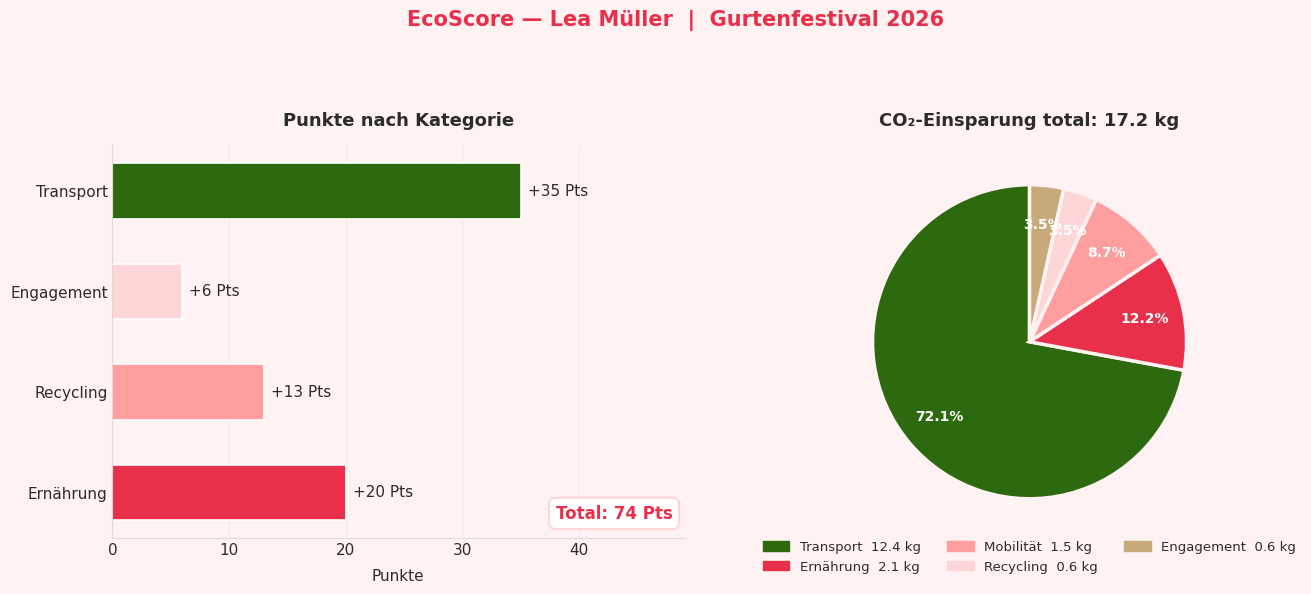

✅ Gespeichert als ecoscore_impact_report.png


In [118]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FFF2F3')

# ── Chart 1 — Punkte nach Kategorie ──────────────────────────────────────────
categories = list(points_by_group.keys())
values = list(points_by_group.values())
colors_bar = ['#E8304A', '#FF9E9E', '#FFD6D8', '#2D6A0F']

bars = ax1.barh(categories, values, color=colors_bar, height=0.55,
                edgecolor='white', linewidth=1.2)
ax1.set_facecolor('#FFF2F3')
ax1.set_xlabel('Punkte', fontsize=11, color='#2C2C2A', labelpad=8)
ax1.set_title('Punkte nach Kategorie', fontsize=13, fontweight='bold',
              color='#2C2C2A', pad=14)
ax1.tick_params(colors='#2C2C2A', labelsize=11)
ax1.set_xlim(0, max(values) + 14)

for bar, val in zip(bars, values):
    ax1.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2,
             f'+{val} Pts', va='center', fontsize=11,
             color='#2C2C2A', fontweight='500')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0D8D9')
ax1.spines['bottom'].set_color('#E0D8D9')
ax1.tick_params(axis='both', which='both', length=0)
ax1.xaxis.grid(True, color='#F0E8E9', linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)

# Score Badge
ax1.text(0.98, 0.04, f'Total: {total_points} Pts',
         transform=ax1.transAxes, ha='right', va='bottom',
         fontsize=12, fontweight='bold', color='#E8304A',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#FFD6D8', linewidth=1.5))

# ── Chart 2 — CO₂ Einsparung ─────────────────────────────────────────────────
co2_labels = list(co2_by_category.keys())
co2_values = list(co2_by_category.values())
colors_pie = ['#2D6A0F', '#E8304A', '#FF9E9E', '#FFD6D8', '#C8A97A']

wedges, texts, autotexts = ax2.pie(
    co2_values,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': '#FFF2F3', 'linewidth': 2.5}
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_facecolor('#FFF2F3')
ax2.set_title(f'CO₂-Einsparung total: {sum(co2_values):.1f} kg',
              fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)

legend_patches = [mpatches.Patch(color=colors_pie[i], label=f'{co2_labels[i]}  {co2_values[i]:.1f} kg')
                  for i in range(len(co2_labels))]
ax2.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9.5,
           frameon=False, labelcolor='#2C2C2A')

# ── Titel ─────────────────────────────────────────────────────────────────────
fig.suptitle('EcoScore — Lea Müller  |  Gurtenfestival 2026',
             fontsize=15, fontweight='bold', color='#E8304A', y=1.02)

plt.tight_layout(pad=2.5)
plt.savefig('ecoscore_impact_report.png', dpi=180, bbox_inches='tight',
            facecolor='#FFF2F3')
plt.show()
print('✅ Gespeichert als ecoscore_impact_report.png')

## 8. Fazit
Der PoC demonstriert erfolgreich den Kernalgorithmus der EcoScore App:

- **Pfad A** — Cashless-Transaktionen werden korrekt kategorisiert und bepunktet
- **Pfad B** — Transportwahl wird korrekt verarbeitet und bepunktet  
- **Reward-Logik** — Tiers werden korrekt freigeschaltet basierend auf Gesamtpunkten
- **Impact Report** — CO₂-Einsparungen werden korrekt nach Kategorie berechnet

In der Zielarchitektur ersetzt eine PostgreSQL-Datenbank die simulierten Daten, und die Transaktionen kommen via Webhook automatisch vom Cashless-System des Gurtenfestivals (vgl. Kapitel 4.3).